# Load and look at a DANDI:002015 NWB file

This notebook shows how to read each part of one NWB file of [DANDI:002015](https://dandiarchive.org/dandiset/002015):

1. Ophys data: planes, ROI table, dF/F, events, and images.
2. Transcriptomics: cell types, cell × gene counts, and all Xenium matches (only for the ROIs that are coregistered in this session, and only neurons).
3. Stimulus: drifting gratings, spontaneous blocks, and natural movies (the movie frames are in `stimulus/templates`).
4. Behavior: running speed, pupil / eye / corneal reflection, and Facemap motion energy + motion SVD.
5. How to find the same cell in the other sessions of the mouse.

Before you start, do one of these (see the README of this repository):

- **On your computer:** make the environment and download the files of one mouse.
- **In a Code Ocean capsule:** attach the data asset `multimodal-nwb_<mouse>_dandi-002015` of one or more mice. The files are then in `/data/sub-<mouse>/`, and nothing is downloaded.
The helper functions are in the `v1_ophys_xenium` package of this repository.

## 0. Find the files

`vx.default_data_dir()` gives the folder with the NWB files:

1. the folder in the environment variable `V1OX_DATA_DIR`, if it is set;
2. `/data` in a Code Ocean capsule that has the data assets of this dataset attached;
3. `data/` in the repository.

On your computer, if the files of the mouse are not there, the next cell downloads them (about 16 GB for one mouse).
Downloads from the embargoed dandiset need the `DANDI_API_KEY` environment variable.
In Code Ocean, `/data` is read-only, so the cell does not download. It tells you which data asset to attach.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from hdmf_zarr import NWBZarrIO

sys.path.insert(0, str(Path.cwd().parent))   # the code/ folder (/code in Code Ocean), if the package is not installed
import v1_ophys_xenium as vx

DATA_DIR = vx.default_data_dir()
MOUSE = "786297"
SESSION = "20250513T091238"   # a drifting-grating session of this mouse
print("data folder:", DATA_DIR, "(Code Ocean)" if vx.in_code_ocean() else "")

files = vx.local_sessions(DATA_DIR)
files = files[files.subject == MOUSE]
if files.empty:
    if vx.in_code_ocean():
        raise FileNotFoundError(f"Attach the data asset multimodal-nwb_{MOUSE}_dandi-002015 to this capsule. "
                                f"Attached mice: {sorted(vx.local_sessions(DATA_DIR).subject.unique())}")
    vx.download_sessions(f"sub-{MOUSE}", DATA_DIR)
    files = vx.local_sessions(DATA_DIR)
    files = files[files.subject == MOUSE]
print(files[["subject", "session", "session_type"]].to_string())

NWB_PATH = files.loc[files.session == SESSION, "path"].iloc[0]

data folder: /data (Code Ocean)
  subject          session       session_type
4  786297  20250512T094640     natural_movies
5  786297  20250513T091238  drifting_gratings
6  786297  20250514T093115  drifting_gratings
7  786297  20250520T093057  drifting_gratings


## 1. Open the file

Keep `io` open while you read data. The traces are read from disk only when you index them (for example `series.data[:, 0]`).
In a script, you can use `with vx.open_nwb(path) as nwb:` instead.

In [2]:
io = NWBZarrIO(str(NWB_PATH), "r")
nwb = io.read()

planes = vx.imaging_planes(nwb)
print("session:", nwb.session_id, "| subject:", nwb.subject.subject_id, "| start:", nwb.session_start_time)
print("genotype:", nwb.subject.genotype)
print("imaging planes:", planes)
print("other processing modules:", [p for p in nwb.processing if p not in planes])
print("intervals:", list(nwb.intervals))
print("stimulus templates:", len(nwb.stimulus_template))

session: multiplane-ophys_786297_2025-05-13_09-12-38 | subject: 786297 | start: 2025-05-13 09:12:38.369537-07:00
genotype: Snap25-IRES2-Cre/wt;Oi4(TIT2L-jGCaMP8s-RiboL1-WPRE-ICL-IRES-tTA2-WPRE)/wt
imaging planes: ['VISp_0', 'VISp_1', 'VISp_2', 'VISp_3', 'VISp_4', 'VISp_5', 'VISp_6', 'VISp_7']
other processing modules: ['behavior', 'transcriptomics']
intervals: ['drifting_gratings_presentations', 'spontaneous_presentations']
stimulus templates: 0


## 2. Ophys data

Each plane is a processing module. It holds the same data as the AIND processed ophys NWB:
`dff_timeseries`, `event_timeseries`, `raw_timeseries`, `neuropil_fluorescence_timeseries`, `neuropil_corrected_timeseries`, `images`, and `image_segmentation/roi_table`.
The plane number is not in depth order. `vx.plane_depths(nwb)` gives the depth of each plane.

Each `roi_table` has 4 more columns:

| Column | Meaning |
|---|---|
| `unique_cell_id` | Cell id that is the same in all 4 sessions of the mouse (`''` if the ROI has no z-stack match) |
| `czstack_id` | Cell id in the cortical z-stack (0 if no match) |
| `is_coregistered` | True if the ROI has a row in the transcriptomics tables: a Xenium match in **this** session that is not a non-neuronal cell |
| `transcriptomics_row` | Row in the `processing/transcriptomics` tables (−1 if none) |

In [3]:
summary = vx.plane_summary(nwb)
print(summary.to_string(index=False))
print("total coregistered ROIs:", summary.n_coregistered.sum())
vx.roi_table(nwb, planes[0]).head()

 plane  depth_um  n_rois  n_soma  n_zstack_matched  n_coregistered
VISp_0       160     442     410               384             368
VISp_1       200     419     393               375             354
VISp_2       120     437     411               379             339
VISp_3       240     496     463               439             387
VISp_4        85     352     328               314             276
VISp_5       280     559     510               477             369
VISp_6        50      91      74                50              34
VISp_7       320     363     342               323               0
total coregistered ROIs: 2127


,is_soma,soma_probability,is_dendrite,dendrite_probability,unique_cell_id,czstack_id,is_coregistered,transcriptomics_row
id,,,,,,,,
0,0,0.236734,0,1.788139e-06,0gupl00455,5370,True,0
1,0,0.000014,0,1.283899e-02,,0,False,-1
2,1,0.995537,0,0.000000e+00,0gupl003sg,4913,True,1
3,0,0.488833,0,7.748604e-07,0gupl003je,4587,True,2
4,1,0.595893,0,7.957220e-06,0gupl003ax,4282,True,3


In [4]:
PLANE = planes[1]
t, dff, roi_ids = vx.traces(nwb, PLANE, "dff")
_, ev, _ = vx.traces(nwb, PLANE, "events")
print(PLANE, "frames:", len(t), "ROIs:", dff.shape[1], f"frame rate: {1/np.median(np.diff(t)):.2f} Hz")

VISp_1 frames: 40350 ROIs: 419 frame rate: 10.74 Hz


### Figure 1: field of view and ROIs

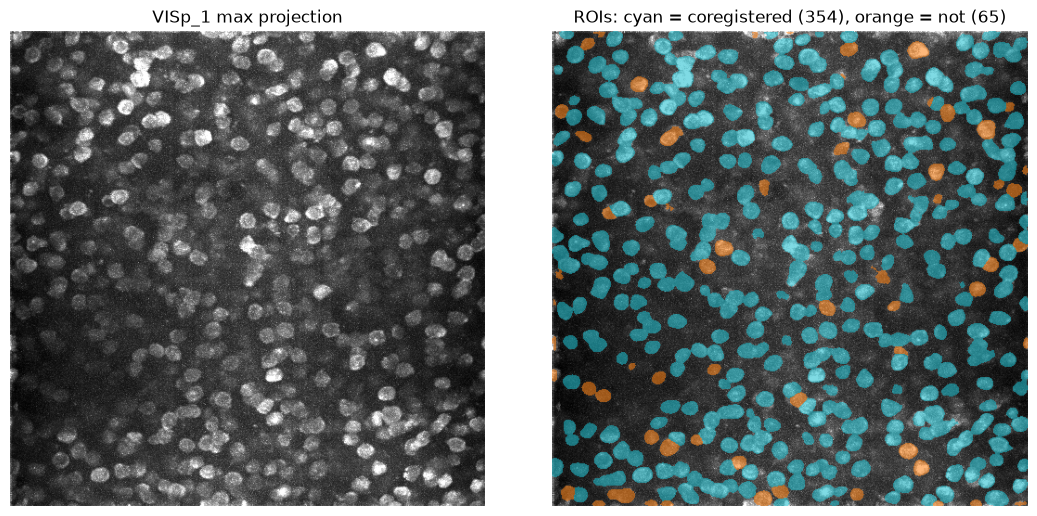

In [5]:
rt = nwb.processing[PLANE]["image_segmentation"]["roi_table"]
img = nwb.processing[PLANE]["images"]["max_projection"].data[:]
seg = nwb.processing[PLANE]["images"]["segmentation_mask_image"].data[:]  # label k = roi_table row k-1
coreg = np.asarray(rt["is_coregistered"].data[:])

label_state = np.zeros(seg.max() + 1, dtype=int)   # 0 background, 1 not coregistered, 2 coregistered
label_state[1:] = np.where(coreg, 2, 1)
state = label_state[seg]

fig, ax = plt.subplots(1, 2, figsize=(11, 5.2))
ax[0].imshow(img, cmap="gray", vmax=np.percentile(img, 99.5))
ax[0].set_title(f"{PLANE} max projection")
ax[1].imshow(img, cmap="gray", vmax=np.percentile(img, 99.5))
ax[1].imshow(np.ma.masked_where(state == 0, state), cmap=plt.matplotlib.colors.ListedColormap(["tab:orange", "tab:cyan"]),
             alpha=0.55, vmin=1, vmax=2)
ax[1].set_title(f"ROIs: cyan = coregistered ({coreg.sum()}), orange = not ({(~coreg).sum()})")
for a in ax:
    a.axis("off")
plt.tight_layout()
plt.show()

**Figure 1.** Left: the maximum projection of one imaging plane. Right: the same image with the ROI masks. Cyan ROIs have a Xenium match in this session. Orange ROIs do not have a match. For the default file (mouse 786297, 2025-05-13, plane VISp_1), 354 of 419 ROIs (84 %) are coregistered, and the unmatched ROIs are spread over the whole field of view. So the coregistration covers the full field of view of this plane. Note: in this mouse the deepest plane (VISp_7, 320 µm) has no coregistered ROIs, because the Xenium sections do not reach that depth.

## 3. Transcriptomics (coregistered ROIs only)

`processing/transcriptomics` has 4 tables:

| Table | Rows | Content |
|---|---|---|
| `cell_types` | one per coregistered ROI | `plane`, `roi_id`, ids, and class / subclass / supertype / cluster (label, name, bootstrapping probability) |
| `cell_by_gene` | same rows as `cell_types` | `counts`: array (n_cells × n_genes) |
| `genes` | one per gene | gene names, in the column order of `counts` |
| `xenium_matches` | one per Xenium match | all matches; `is_primary` marks the match used in the other tables |

The tables hold only neurons. ROIs matched to non-neuronal cells (ABC classes 30–34: astrocytes, oligodendrocytes and OPCs, vascular and immune cells) are not included; the module description gives their number. A few ROIs have a Xenium match but no cell-type mapping. They stay in the tables, with names `''` and probabilities NaN.

In [6]:
tx = vx.transcriptomics(nwb)
cell_types, counts, matches = tx["cell_types"], tx["counts"], tx["xenium_matches"]
genes = counts.columns.to_numpy()

print(nwb.processing["transcriptomics"].description)
print("coregistered ROIs:", len(cell_types), "| genes:", len(genes))
print("ROIs with more than one Xenium match:", int((cell_types.n_xenium_matches > 1).sum()))
print("ROIs with no cell-type mapping:", int((cell_types.subclass_name == "").sum()))
cell_types[["plane", "roi_id", "unique_cell_id", "xenium_section", "xenium_cell_id",
            "subclass_name", "subclass_bootstrapping_probability", "supertype_name"]].head()

Xenium spatial transcriptomics for ROIs coregistered in this session (ophys_session_1 of the match table). Sources: Xenium_786297_2025-07-16_processed, Xenium_786297_2025-07-16_mapped, ophys_transcriptomics_match_tables/786297x_ophys_transcriptomics_match_all.csv. Primary Xenium match = lowest section number. Only neurons: 53 ROIs matched to non-neuronal cells (ABC classes 30-34) are not included. Rows with no cell type: 110; rows with no gene counts (counts = -1): 0.
coregistered ROIs: 2127 | genes: 299
ROIs with more than one Xenium match: 356
ROIs with no cell-type mapping: 110


,plane,roi_id,unique_cell_id,xenium_section,xenium_cell_id,subclass_name,subclass_bootstrapping_probability,supertype_name
id,,,,,,,,
0,VISp_0,0,0gupl00455,11,11267,007 L2/3 IT CTX Glut,0.98,0030 L2/3 IT CTX Glut_2
1,VISp_0,2,0gupl003sg,10,7703,007 L2/3 IT CTX Glut,1.00,0030 L2/3 IT CTX Glut_2
2,VISp_0,3,0gupl003je,10,72,007 L2/3 IT CTX Glut,0.99,0030 L2/3 IT CTX Glut_2
3,VISp_0,4,0gupl003ax,9,4686,049 Lamp5 Gaba,0.97,0199 Lamp5 Gaba_1
4,VISp_0,5,0gupl00422,10,3828,006 L4/5 IT CTX Glut,0.80,0024 L4/5 IT CTX Glut_2


### Figure 2: cell types of the coregistered ROIs

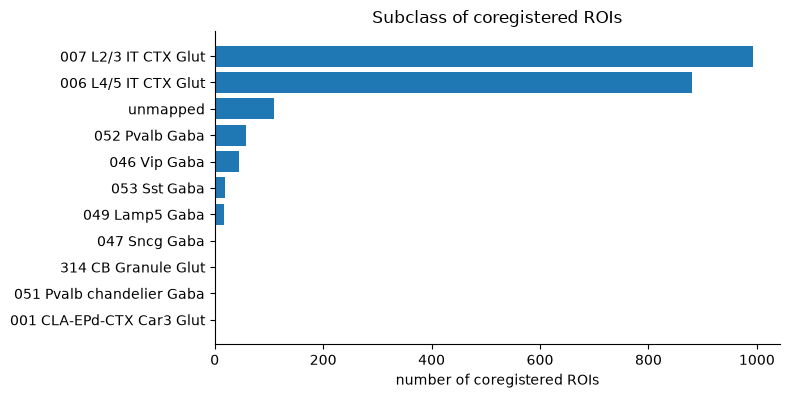

In [7]:
sub = cell_types.subclass_name.replace("", "unmapped").value_counts()
fig, ax = plt.subplots(figsize=(8, 0.28 * len(sub) + 1))
ax.barh(sub.index[::-1], sub.values[::-1], color="tab:blue")
ax.set_xlabel("number of coregistered ROIs")
ax.set_title("Subclass of coregistered ROIs")
for s in ("top", "right"):
    ax.spines[s].set_visible(False)
plt.tight_layout()
plt.show()

**Figure 2.** The number of coregistered ROIs in each ABC-atlas subclass. For the default file, L2/3 IT and L4/5 IT are the two largest groups (about 990 and 880 ROIs). Pvalb, Vip, Sst and Lamp5 have between about 15 and 60 ROIs each. There are no non-neuronal subclasses, because they are removed from the file. 110 ROIs ("unmapped") have a Xenium match but no cell-type mapping. Thus most coregistered ROIs are excitatory neurons, and each interneuron subclass has only a small number of cells.

### Figure 3: marker genes by subclass

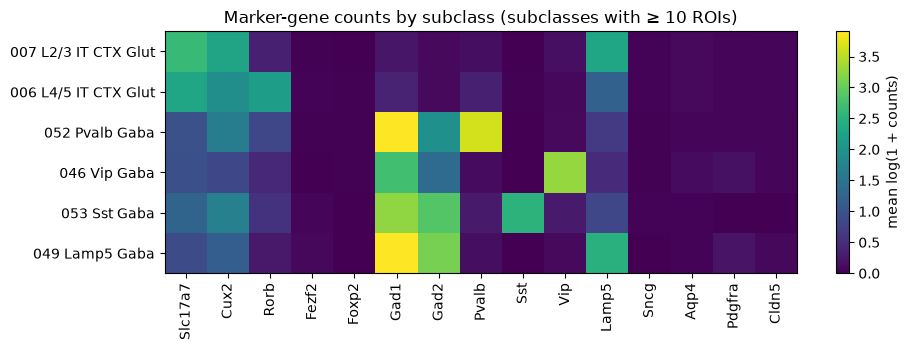

In [8]:
markers = [g for g in ["Slc17a7", "Cux2", "Rorb", "Fezf2", "Foxp2", "Gad1", "Gad2", "Pvalb", "Sst", "Vip",
                       "Lamp5", "Sncg", "Aqp4", "Pdgfra", "Cldn5"] if g in genes]
keep = cell_types.subclass_name.value_counts()
keep = keep[(keep >= 10) & (keep.index != "")].index
mean_counts = (np.log1p(counts[markers])
               .groupby(cell_types.subclass_name).mean().loc[keep])
fig, ax = plt.subplots(figsize=(0.45 * len(markers) + 3, 0.35 * len(keep) + 1.5))
im = ax.imshow(mean_counts.to_numpy(), aspect="auto", cmap="viridis")
ax.set_xticks(range(len(markers)), markers, rotation=90)
ax.set_yticks(range(len(keep)), keep)
plt.colorbar(im, ax=ax, label="mean log(1 + counts)")
ax.set_title("Marker-gene counts by subclass (subclasses with ≥ 10 ROIs)")
plt.tight_layout()
plt.show()

**Figure 3.** The mean log(1 + count) of marker genes in each mapped subclass that has 10 or more coregistered ROIs. Each subclass has high counts of its own markers: *Gad1*/*Gad2* in the GABAergic subclasses, *Pvalb* in Pvalb cells, *Sst* in Sst cells, *Vip* in Vip cells, and *Rorb* in L4/5 IT cells. The non-neuronal markers (*Aqp4*, *Pdgfra*, *Cldn5*) are low in all rows, as expected for tables that hold only neurons. Thus the gene counts in the file agree with the cell-type labels.

### Join the cell types to the ROI traces

`cell_types.plane` and `cell_types.roi_id` give the ROI. The dF/F column for that ROI is the index of `roi_id` in the `rois` of the trace series.
`vx.celltype_traces` does this for all coregistered ROIs of one subclass.

In [9]:
subclasses = [s for s in cell_types.subclass_name.value_counts().index if s][:6]
print(subclasses)

['007 L2/3 IT CTX Glut', '006 L4/5 IT CTX Glut', '052 Pvalb Gaba', '046 Vip Gaba', '053 Sst Gaba', '049 Lamp5 Gaba']


## 4. Stimulus

The stimulus is in `nwb.intervals`. The times are on the sync clock (s) and are corrected with the measured monitor delay (see the table description). The times from the original stimulus table are in `start_time_uncorrected` / `stop_time_uncorrected`.

- Drifting-grating sessions: `drifting_gratings_presentations`, one row per trial.
- Movie session: `natural_movie_presentations`, one row per shown movie frame. The frames are in `nwb.stimulus_template[movie_name]`.
- All sessions: `spontaneous_presentations` (gray screen).

In [10]:
for name, ti in nwb.intervals.items():
    print(f"{name}: {len(ti)} rows")
    print("   ", ti.description[:250])
IS_MOVIE = vx.is_movie_session(nwb)
stim, spont = vx.stimulus_tables(nwb)
stim.head()

drifting_gratings_presentations: 1120 rows
    Drifting-grating trials. Times = stim-table time - 35.1 ms + measured monitor delay 53.7 ms (shift +18.6 ms). Original times are in *_uncorrected columns.
spontaneous_presentations: 4 rows
    Gray-screen spontaneous blocks. Times = stim-table time - 35.1 ms + measured monitor delay 53.7 ms (shift +18.6 ms). Original times are in *_uncorrected columns.


,start_time,stop_time,stim_name,stim_block,contrast,temporal_frequency,spatial_frequency,orientation,stim_index,start_time_uncorrected,stop_time_uncorrected
id,,,,,,,,,,,
0,42.930270,44.931940,drifting_gratings_contrast,0,0.10,1.0,0.04,45.0,0,42.911670,44.913340
1,45.932809,47.934479,drifting_gratings_contrast,0,0.05,1.0,0.04,45.0,0,45.914209,47.915879
2,48.935280,50.936950,drifting_gratings_contrast,0,0.80,1.0,0.04,225.0,0,48.916680,50.918350
3,51.937629,53.939399,drifting_gratings_contrast,0,0.20,1.0,0.04,45.0,0,51.919029,53.920799
4,54.940230,56.941870,drifting_gratings_contrast,0,0.40,1.0,0.04,180.0,0,54.921630,56.923270


### Figure 4: stimulus-aligned responses by subclass (drifting-grating sessions)

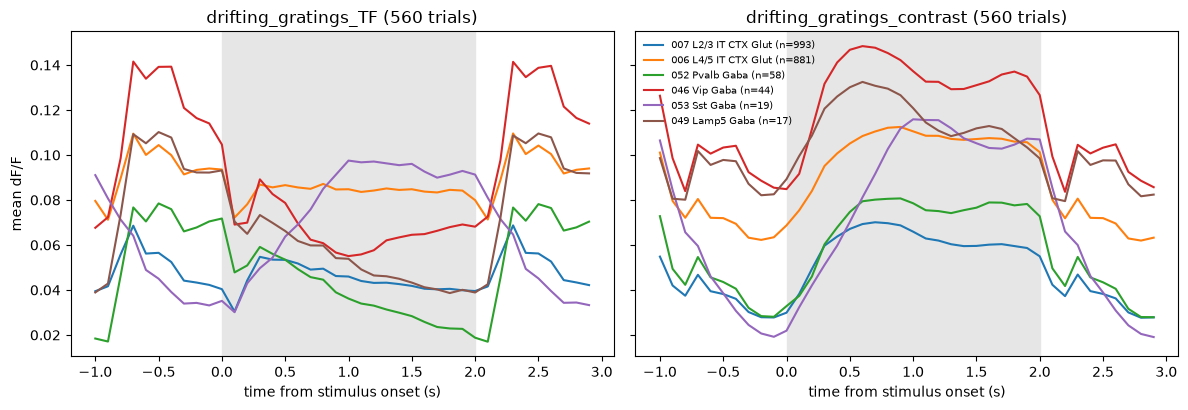

In [11]:
if not IS_MOVIE:
    pre, post, dt = 1.0, 3.0, 0.1
    lags = np.arange(-pre, post, dt)
    fig, axes = plt.subplots(1, 2, figsize=(12, 4.2), sharey=True)
    for ax, (stim_name, grp) in zip(axes, stim.groupby("stim_name")):
        for sc in subclasses:
            tt, x, rows_sc = vx.celltype_traces(nwb, cell_types, sc)
            x = x.mean(axis=1)
            psth = np.array([np.interp(o + lags, tt, x) for o in grp.start_time])
            ax.plot(lags, psth.mean(0), label=f"{sc} (n={len(rows_sc)})")
        dur = (grp.stop_time - grp.start_time).median()
        ax.axvspan(0, dur, color="0.9", zorder=0)
        ax.set_title(f"{stim_name} ({len(grp)} trials)")
        ax.set_xlabel("time from stimulus onset (s)")
    axes[0].set_ylabel("mean dF/F")
    axes[1].legend(fontsize=7, frameon=False)
    plt.tight_layout()
    plt.show()
else:
    print("Movie session: see Figure 6 for the movie frames.")

**Figure 4.** The mean dF/F of each subclass around the drifting-grating onsets. Left: the temporal-frequency (TF) block. Right: the contrast block. The gray band is the 2 s stimulus. For the default file, all subclasses increase their activity during the stimulus in the contrast block, and Vip cells have the highest dF/F. In the TF block, most subclasses have their strongest response about 0.3 s after the stimulus offset (the peak before 0 s is the offset response to the previous trial), but Sst cells increase their activity during the stimulus. So the two blocks give different response time courses. This example shows how to use `intervals` and `cell_types` together to get cell-type-specific responses.

## 5. Behavior

`processing/behavior` holds:

| Interface | Series |
|---|---|
| `running` | `running_speed` (cm/s), `running_speed_filtered` |
| `pupil_tracking` | `pupil_area`, `pupil_width`, `pupil_height`, `pupil_center_x/y`, `pupil_phi`, `pupil_average_confidence`, `pupil_is_bad_frame` |
| `eye_tracking` | the same quantities for the eye ellipse |
| `corneal_reflection_tracking` | the same quantities for the corneal reflection (CR) |
| `facemap_motion_energy` | `<region>_motion_energy`, `_motion_energy_clean`, `_is_keyframe_contaminated` for face, nose, behavior (body) |
| `facemap_motion_svd` | `<region>_motion_svd`: array (frames × 100 PCs) |

All timestamps are on the sync clock (s), the same clock as the ophys data.
Mice 778174 and 797371 have no pupil or Facemap data, and the movie session of 810976 has no nose region. For these files, the next cells print a message and skip the missing series.

In [12]:
beh = nwb.processing["behavior"]
for name, iface in beh.data_interfaces.items():
    print(name, "->", list(iface.time_series))
HAS_VIDEO = "pupil_tracking" in beh.data_interfaces and "facemap_motion_svd" in beh.data_interfaces

t_run, run = vx.behavior_series(nwb, "running", "running_speed")
if HAS_VIDEO:
    t_pup, pupil = vx.behavior_series(nwb, "pupil_tracking", "pupil_area")
    _, pupil_bad = vx.behavior_series(nwb, "pupil_tracking", "pupil_is_bad_frame")
    t_face, face_me = vx.behavior_series(nwb, "facemap_motion_energy", "face_motion_energy_clean")
    _, face_svd = vx.behavior_series(nwb, "facemap_motion_svd", "face_motion_svd")
    print("running", len(t_run), "| pupil", len(t_pup), "| face", len(t_face), "| face SVD", face_svd.shape)
else:
    print("This file has no pupil or Facemap data.")

corneal_reflection_tracking -> ['cr_area', 'cr_average_confidence', 'cr_center_x', 'cr_center_y', 'cr_height', 'cr_is_bad_frame', 'cr_phi', 'cr_width']
eye_tracking -> ['eye_area', 'eye_average_confidence', 'eye_center_x', 'eye_center_y', 'eye_height', 'eye_is_bad_frame', 'eye_phi', 'eye_width']
facemap_motion_energy -> ['behavior_is_keyframe_contaminated', 'behavior_motion_energy', 'behavior_motion_energy_clean', 'face_is_keyframe_contaminated', 'face_motion_energy', 'face_motion_energy_clean', 'nose_is_keyframe_contaminated', 'nose_motion_energy', 'nose_motion_energy_clean']
facemap_motion_svd -> ['behavior_motion_svd', 'face_motion_svd', 'nose_motion_svd']
pupil_tracking -> ['pupil_area', 'pupil_average_confidence', 'pupil_center_x', 'pupil_center_y', 'pupil_height', 'pupil_is_bad_frame', 'pupil_phi', 'pupil_width']
running -> ['running_speed', 'running_speed_filtered']
running 224520 | pupil 227127 | face 226860 | face SVD (226860, 100)


### Figure 5: behavior over the session

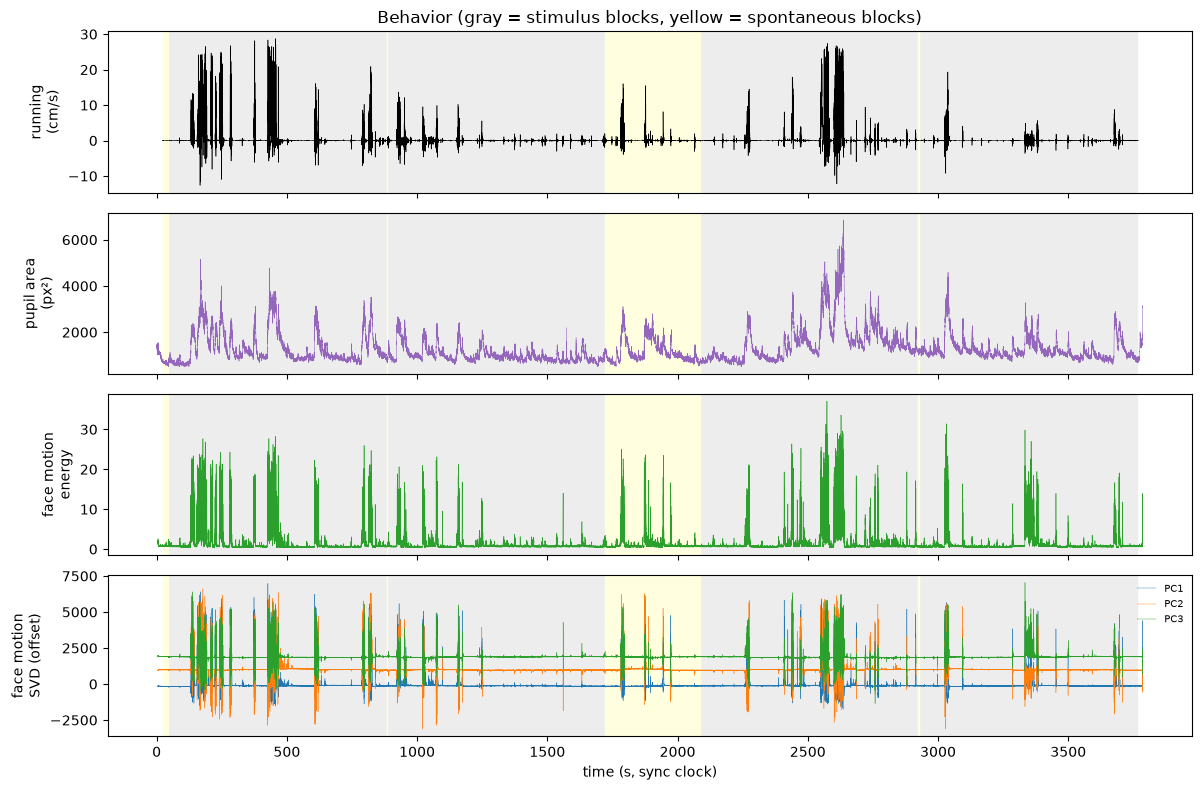

In [13]:
n_rows = 4 if HAS_VIDEO else 1
fig, ax = plt.subplots(n_rows, 1, figsize=(12, 2 * n_rows), sharex=True, squeeze=False)
ax = ax[:, 0]
ax[0].plot(t_run, run[:], lw=0.4, color="k"); ax[0].set_ylabel("running\n(cm/s)")
if HAS_VIDEO:
    pup = np.asarray(pupil[:], float)
    pup[np.asarray(pupil_bad[:]) > 0] = np.nan
    svd3 = face_svd[:, :3]
    ax[1].plot(t_pup, pup, lw=0.4, color="tab:purple"); ax[1].set_ylabel("pupil area\n(px²)")
    ax[2].plot(t_face, face_me[:], lw=0.4, color="tab:green"); ax[2].set_ylabel("face motion\nenergy")
    for k in range(3):
        ax[3].plot(t_face, svd3[:, k] + 3 * k * np.nanstd(svd3[:, 0]), lw=0.3, label=f"PC{k+1}")
    ax[3].set_ylabel("face motion\nSVD (offset)"); ax[3].legend(fontsize=7, frameon=False, loc="upper right")
ax[-1].set_xlabel("time (s, sync clock)")
for a in ax:
    for _, b in stim.groupby("stim_block"):
        a.axvspan(b.start_time.min(), b.stop_time.max(), color="0.93", zorder=0)
    for _, r in spont.iterrows():
        a.axvspan(r.start_time, r.stop_time, color="lightyellow", zorder=0)
ax[0].set_title("Behavior (gray = stimulus blocks, yellow = spontaneous blocks)")
plt.tight_layout()
plt.show()

**Figure 5.** Running speed, pupil area, face motion energy, and the first 3 face motion-SVD components during the whole session. Gray bands are stimulus blocks and yellow bands are spontaneous blocks. For the default file, the pupil area, the face motion energy and the motion-SVD components all increase at the same times as the running bouts. So the behavior signals in the file are on one clock and agree with each other.

### Put behavior and neural data on one time base

Behavior is sampled at about 60 Hz and ophys at about 10.7 Hz. `vx.align_to` puts a behavior signal on the ophys frame times (linear interpolation; NaN samples are ignored).

In [14]:
run_on_ophys = vx.align_to(t, t_run, run[:])
if HAS_VIDEO:
    pup_on_ophys = vx.align_to(t, t_pup, pup)

x = dff[:, :]
r_run = np.array([np.corrcoef(run_on_ophys, x[:, j])[0, 1] for j in range(x.shape[1])])
rows = cell_types[cell_types.plane == PLANE].set_index("roi_id")
col_sub = pd.Series(rows.subclass_name).reindex(roi_ids).fillna("not coregistered").replace("", "unmapped")
print(pd.DataFrame({"r_running": r_run, "subclass": col_sub.to_numpy()})
      .groupby("subclass").r_running.agg(["count", "mean"]).round(3).sort_values("count", ascending=False))

                      count   mean
subclass                          
006 L4/5 IT CTX Glut    177  0.013
007 L2/3 IT CTX Glut    112  0.016
not coregistered         65  0.013
unmapped                 46  0.027
052 Pvalb Gaba           10  0.111
053 Sst Gaba              4 -0.007
049 Lamp5 Gaba            3  0.197
046 Vip Gaba              2  0.282


## 6. Natural movies (movie session only)

In the movie-session file (`..._behavior+image+ophys.nwb.zarr`), every movie is an `ImageSeries` in `nwb.stimulus_template` (uint8, frames × 300 × 480).
Row *i* of `natural_movie_presentations` tells which frame (`frame`) of which movie (`movie_name`) was on the screen from `start_time` to `stop_time`.

In [15]:
movie_files = files[files.session_type == "natural_movies"].path.tolist()
if IS_MOVIE:
    mnwb, mio = nwb, None
elif movie_files:
    mio = NWBZarrIO(str(movie_files[0]), "r"); mnwb = mio.read()
else:
    mnwb = None
    print("The movie-session file of this mouse is not downloaded (or its data asset is not attached).")

if mnwb is not None:
    mv = mnwb.intervals["natural_movie_presentations"].to_dataframe()
    names = list(mnwb.stimulus_template)
    print(len(names), "movies; shown frames:", len(mv))
    print(mv.groupby("movie_name").frame.agg(["count", "max"]).head())

56 movies; shown frames: 137370
              count   max
movie_name               
Session_0_00   1590  1589
Session_0_01   1350  1349
Session_0_02   1560  1559
Session_0_03   1440  1439
Session_0_04   2160  2159


### Figure 6: movie frames

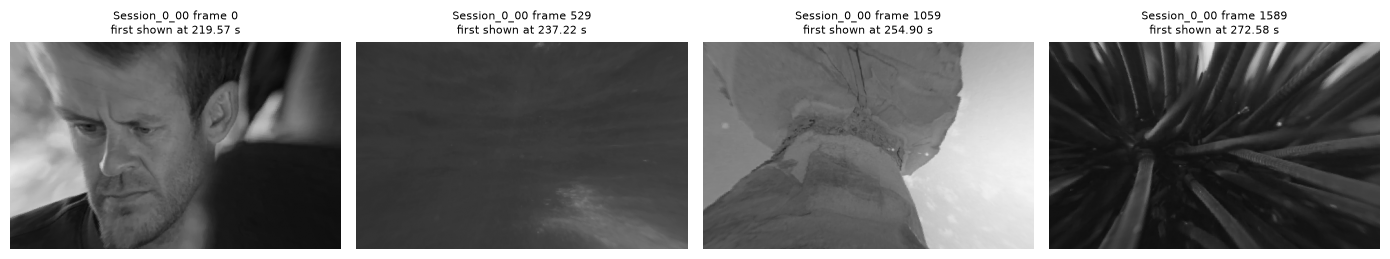

In [16]:
if mnwb is not None:
    name = names[0]
    movie = mnwb.stimulus_template[name].data
    idx = np.linspace(0, movie.shape[0] - 1, 4).astype(int)
    fig, ax = plt.subplots(1, 4, figsize=(14, 2.8))
    for a, k in zip(ax, idx):
        a.imshow(movie[k], cmap="gray", vmin=0, vmax=255)
        on = mv[(mv.movie_name == name) & (mv.frame == k)].start_time
        a.set_title(f"{name} frame {k}\nfirst shown at {on.min():.2f} s", fontsize=8)
        a.axis("off")
    plt.tight_layout()
    plt.show()

**Figure 6.** Four frames of the first natural movie, from the movie-session file. Each title gives the frame index and the first time that the frame was on the screen (from `natural_movie_presentations`). For mouse 786297, frames that are 529 apart were shown 17.6–17.7 s apart, which agrees with the 30 Hz frame rate of the movie. So the frame index and the times in the file are correct, and you can use them to get the image that was on the screen at any ophys frame.

## 7. The same cell in other sessions

`unique_cell_id` is the same in the 4 files of a mouse. The coregistered set is different in each session, so do an inner join on `unique_cell_id` to find the cells that are coregistered in two sessions.

In [17]:
sets = {r.session: vx.coregistered_cells(r.path) for r in files.itertuples()}
for d, c in sets.items():
    print(d, len(c), "coregistered ROIs")
if len(sets) > 1:
    (d1, c1), (d2, c2) = list(sets.items())[:2]
    both = c1.merge(c2, on="unique_cell_id", suffixes=(f"_{d1}", f"_{d2}"))
    print(f"coregistered in both {d1} and {d2}: {len(both)}")
    display(both.head()) if "display" in globals() else print(both.head())

20250512T094640 2112 coregistered ROIs
20250513T091238 2127 coregistered ROIs
20250514T093115 1941 coregistered ROIs
20250520T093057 2054 coregistered ROIs
coregistered in both 20250512T094640 and 20250513T091238: 1299
  plane_20250512T094640  roi_id_20250512T094640 unique_cell_id  \
0                VISp_0                       0     0gupl00455   
1                VISp_0                      10     0gupl003ax   
2                VISp_0                      13     0gupl00422   
3                VISp_0                      14     0gupl00420   
4                VISp_0                      18     0gupl0043t   

  subclass_name_20250512T094640 plane_20250513T091238  roi_id_20250513T091238  \
0          007 L2/3 IT CTX Glut                VISp_0                       0   
1                049 Lamp5 Gaba                VISp_0                       4   
2          006 L4/5 IT CTX Glut                VISp_0                       5   
3                                              VISp_0       

In [18]:
io.close()
if mnwb is not None and mio is not None:
    mio.close()